# Actividad 2: Red Neuronal Básica Entrenable

En esta actividad, Se implentara una red neuronal básica con una capa oculta, entrenable mediante backpropagation. Compararemos las funciones de activación sigmoid y ReLU, manteniendo constantes otros parámetros para una comparación válida.

In [1]:
# Importamos las bibliotecas necesarias para el proyecto
import numpy as np  # NumPy para operaciones matemáticas y manejo de arrays
import matplotlib.pyplot as plt  # Matplotlib para crear gráficos y visualizaciones
from sklearn.datasets import make_classification  # Función de scikit-learn para generar datos de clasificación sintéticos
from sklearn.model_selection import train_test_split  # Función para dividir los datos en conjuntos de entrenamiento y prueba

In [2]:
# Definimos las funciones de activación y sus derivadas, que son esenciales para las redes neuronales
# La función sigmoid comprime los valores de entrada entre 0 y 1, útil para salidas de probabilidad
def sigmoid(x):
    # Calcula la función sigmoid: 1 / (1 + e^(-x)), donde e es el número de Euler
    return 1 / (1 + np.exp(-x))

# La derivada de sigmoid se usa en backpropagation para calcular gradientes
def sigmoid_derivative(x):
    # Derivada de sigmoid: sigmoid(x) * (1 - sigmoid(x)), pero aquí x ya es sigmoid(a1) o sigmoid(a2)
    return x * (1 - x)

# ReLU (Rectified Linear Unit) es una función de activación que devuelve x si x > 0, sino 0
def relu(x):
    # Usa np.maximum para devolver el máximo entre 0 y x, efectivamente "rectificando" valores negativos
    return np.maximum(0, x)

# La derivada de ReLU es 1 para x > 0 y 0 para x <= 0
def relu_derivative(x):
    # np.where devuelve 1 donde x > 0, y 0 en caso contrario
    return np.where(x > 0, 1, 0)

In [3]:
# Definimos una clase para una Red Neuronal Simple con una capa oculta
class SimpleNN:
    # El constructor inicializa la red con tamaños de capas y tipo de activación
    def __init__(self, input_size, hidden_size, output_size, activation='sigmoid'):
        # Guardamos los parámetros de la red
        self.input_size = input_size  # Número de neuronas en la capa de entrada
        self.hidden_size = hidden_size  # Número de neuronas en la capa oculta
        self.output_size = output_size  # Número de neuronas en la capa de salida
        self.activation = activation  # Tipo de función de activación ('sigmoid' o 'relu')

        # Inicializamos los pesos y biases de manera aleatoria para W y cero para b
        # W1 conecta entrada a oculta: forma (input_size, hidden_size)
        self.W1 = np.random.randn(self.input_size, self.hidden_size)
        # b1 es el bias para la capa oculta: forma (1, hidden_size)
        self.b1 = np.zeros((1, self.hidden_size))
        # W2 conecta oculta a salida: forma (hidden_size, output_size)
        self.W2 = np.random.randn(self.hidden_size, self.output_size)
        # b2 es el bias para la capa de salida: forma (1, output_size)
        self.b2 = np.zeros((1, self.output_size))

    # Método forward: calcula la salida de la red para una entrada X
    def forward(self, X):
        # Calculamos la activación lineal de la capa oculta: z1 = X * W1 + b1
        self.z1 = np.dot(X, self.W1) + self.b1
        # Aplicamos la función de activación seleccionada
        if self.activation == 'sigmoid':
            self.a1 = sigmoid(self.z1)  # Activación sigmoid para la capa oculta
        elif self.activation == 'relu':
            self.a1 = relu(self.z1)  # Activación ReLU para la capa oculta

        # Calculamos la activación lineal de la capa de salida: z2 = a1 * W2 + b2
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        # Aplicamos sigmoid a la salida para obtener probabilidades (clasificación binaria)
        self.a2 = sigmoid(self.z2)

        return self.a2  # Devolvemos la salida final

    # Método backward: implementa backpropagation para actualizar pesos
    def backward(self, X, y, output, learning_rate):
        # Calculamos el error en la capa de salida: diferencia entre predicción y verdad
        output_error = y - output
        # Calculamos el delta para la capa de salida: error * derivada de sigmoid
        output_delta = output_error * sigmoid_derivative(output)

        # Propagamos el error hacia atrás a la capa oculta
        hidden_error = np.dot(output_delta, self.W2.T)
        # Calculamos el delta para la capa oculta según la activación
        if self.activation == 'sigmoid':
            hidden_delta = hidden_error * sigmoid_derivative(self.a1)
        elif self.activation == 'relu':
            hidden_delta = hidden_error * relu_derivative(self.a1)

        # Actualizamos los pesos y biases usando gradiente descendente
        # Actualización de W2: W2 += a1.T * output_delta * learning_rate
        self.W2 += np.dot(self.a1.T, output_delta) * learning_rate
        # Actualización de b2: suma de output_delta por columnas
        self.b2 += np.sum(output_delta, axis=0, keepdims=True) * learning_rate
        # Actualización de W1: W1 += X.T * hidden_delta * learning_rate
        self.W1 += np.dot(X.T, hidden_delta) * learning_rate
        # Actualización de b1: suma de hidden_delta por columnas
        self.b1 += np.sum(hidden_delta, axis=0, keepdims=True) * learning_rate

    # Método train: entrena la red por un número de épocas
    def train(self, X, y, epochs, learning_rate):
        losses = []  # Lista para almacenar el loss en cada época
        for epoch in range(epochs):  # Bucle sobre el número de épocas
            output = self.forward(X)  # Forward pass con los datos de entrenamiento
            loss = np.mean((y - output)**2)  # Calculamos el Mean Squared Error (MSE)
            losses.append(loss)  # Guardamos el loss actual
            self.backward(X, y, output, learning_rate)  # Backward pass para actualizar pesos
            if epoch % 100 == 0:  # Imprimimos el loss cada 100 épocas
                print(f'Epoch {epoch}, Loss: {loss:.4f}')
        return losses  # Devolvemos la lista de losses para análisis

In [4]:
# Generamos un conjunto de datos sintéticos para clasificación binaria usando scikit-learn
# make_classification crea datos con 2 clases separables
X, y = make_classification(n_samples=1000,  # Número total de muestras: 1000
                           n_features=2,  # Número de características (dimensiones): 2
                           n_informative=2,  # Número de características informativas: 2
                           n_redundant=0,  # Número de características redundantes: 0
                           n_clusters_per_class=1,  # Un cluster por clase para simplicidad
                           random_state=42)  # Semilla para reproducibilidad
y = y.reshape(-1, 1)  # Redimensionamos y a forma (1000, 1) para compatibilidad con la red
# Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Ejemplo de la Vida Real para `make_classification`

Imaginemos que estamos tratando de **predecir si un cliente va a comprar un producto en una tienda online** basándonos en su comportamiento de navegación. La 'clase' que queremos predecir sería 'compró' o 'no compró'.

Así es como se traducirían los parámetros de `make_classification` en este contexto:

1.  **`n_samples` (Número total de muestras):**
    *   Si recopilamos datos de **1000 clientes** diferentes (sus hábitos de navegación y si compraron o no), entonces `n_samples = 1000`. Cada cliente es una 'muestra' o una fila en nuestro conjunto de datos.

2.  **`n_features` (Número de características o dimensiones):**
    *   Para cada uno de esos 1000 clientes, podríamos recopilar dos tipos de información:
        *   **1. Tiempo total que pasaron en el sitio web (en minutos).**
        *   **2. Número de artículos que agregaron al carrito.**
    *   Entonces, `n_features = 2`. Nuestros datos de cliente se representarían como puntos en un plano 2D.

3.  **`n_informative` (Número de características informativas):**
    *   De nuestras dos características (`tiempo_en_sitio_web` y `articulos_en_carrito`), si **ambas son realmente útiles** para saber si alguien va a comprar (es decir, tanto el tiempo como los artículos en el carrito nos ayudan a diferenciar entre compradores y no compradores), entonces `n_informative = 2`.

4.  **`n_redundant` (Número de características redundantes):**
    *   En este ejemplo, `n_redundant = 0` significa que todas las características que generamos son informativas y ninguna duplica la información de otra.
    *   *(Si tuviéramos una característica como 'tiempo_en_paginas_producto' que siempre es proporcional al 'tiempo_en_sitio_web', esa sería una característica redundante).*

5.  **`n_clusters_per_class` (Número de cúmulos por clase):**
    *   **`n_clusters_per_class = 1`:** Esto significaría que, dentro del grupo de clientes que 'compran', todos exhiben un patrón de comportamiento similar (por ejemplo, todos pasan mucho tiempo y añaden varios artículos). Lo mismo aplicaría para los que 'no compran'.
    *   *(Si fuera `n_clusters_per_class = 2`, podría haber dos tipos distintos de clientes que compran: los que investigan mucho y los que compran rápidamente un solo artículo caro, haciendo la clasificación más compleja).*

6.  **`random_state` (Semilla para reproducibilidad):**
    *   Usar `random_state = 42` asegura que, si generamos 1000 clientes simulados para nuestro estudio, cada vez que ejecutemos el código con este valor, obtendremos **exactamente los mismos 1000 clientes simulados con los mismos datos de comportamiento**. Esto es vital para la consistencia y comparación de resultados.

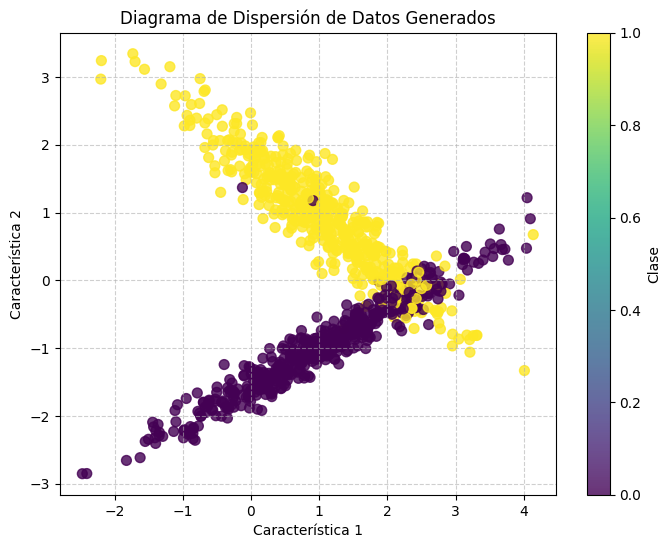

In [5]:
# Importamos la biblioteca matplotlib.pyplot para crear gráficos
import matplotlib.pyplot as plt

# Creamos una figura con un tamaño específico (ancho=8 pulgadas, alto=6 pulgadas)
plt.figure(figsize=(8, 6))
# Generamos un gráfico de dispersión (scatter plot) de los datos.
# X[:, 0] son los valores de la primera característica (eje x).
# X[:, 1] son los valores de la segunda característica (eje y).
# c=y.flatten() colorea los puntos según los valores de la etiqueta 'y'.
# cmap='viridis' define el mapa de colores a usar.
# s=50 establece el tamaño de los puntos.
# alpha=0.8 ajusta la transparencia de los puntos.
plt.scatter(X[:, 0], X[:, 1], c=y.flatten(), cmap='viridis', s=50, alpha=0.8)
# Establecemos el título del gráfico.
plt.title('Diagrama de Dispersión de Datos Generados')
# Etiquetamos el eje X.
plt.xlabel('Característica 1')
# Etiquetamos el eje Y.
plt.ylabel('Característica 2')
# Añadimos una barra de color para indicar a qué clase corresponde cada color.
plt.colorbar(label='Clase')
# Añadimos una cuadrícula al gráfico para mejor legibilidad.
# linestyle='--' crea líneas discontinuas y alpha=0.6 las hace semitransparentes.
plt.grid(True, linestyle='--', alpha=0.6)
# Mostramos el gráfico.
plt.show()

In [6]:
# Creamos una instancia de la red neuronal con activación sigmoid
nn_sigmoid = SimpleNN(input_size=2,  # 2 neuronas de entrada (2 características)
                      hidden_size=4,  # 4 neuronas en la capa oculta
                      output_size=1,  # 1 neurona de salida (clasificación binaria)
                      activation='sigmoid')  # Usamos sigmoid como función de activación
# Entrenamos la red con los datos de entrenamiento
losses_sigmoid = nn_sigmoid.train(X_train,  # Datos de entrada de entrenamiento
                                  y_train,  # Etiquetas de entrenamiento
                                  epochs=1000,  # Número de épocas: 1000 iteraciones completas
                                  learning_rate=0.1)  # Tasa de aprendizaje: 0.1

Epoch 0, Loss: 0.2833
Epoch 100, Loss: 0.0506
Epoch 200, Loss: 0.0457
Epoch 300, Loss: 0.0429
Epoch 400, Loss: 0.0418
Epoch 500, Loss: 0.0412
Epoch 600, Loss: 0.0408
Epoch 700, Loss: 0.0405
Epoch 800, Loss: 0.0402
Epoch 900, Loss: 0.0399


In [7]:
# Creamos otra instancia de la red neuronal, esta vez con activación ReLU
nn_relu = SimpleNN(input_size=2,  # 2 neuronas de entrada
                   hidden_size=4,  # 4 neuronas ocultas
                   output_size=1,  # 1 neurona de salida
                   activation='relu')  # Usamos ReLU como función de activación
# Entrenamos esta red con los mismos datos de entrenamiento
losses_relu = nn_relu.train(X_train,  # Datos de entrada
                            y_train,  # Etiquetas
                            epochs=1000,  # 1000 épocas
                            learning_rate=0.1)  # Tasa de aprendizaje 0.1

Epoch 0, Loss: 0.4657
Epoch 100, Loss: 0.0474
Epoch 200, Loss: 0.0538
Epoch 300, Loss: 0.0444
Epoch 400, Loss: 0.0425
Epoch 500, Loss: 0.0423
Epoch 600, Loss: 0.0498
Epoch 700, Loss: 0.0434
Epoch 800, Loss: 0.0424
Epoch 900, Loss: 0.0423


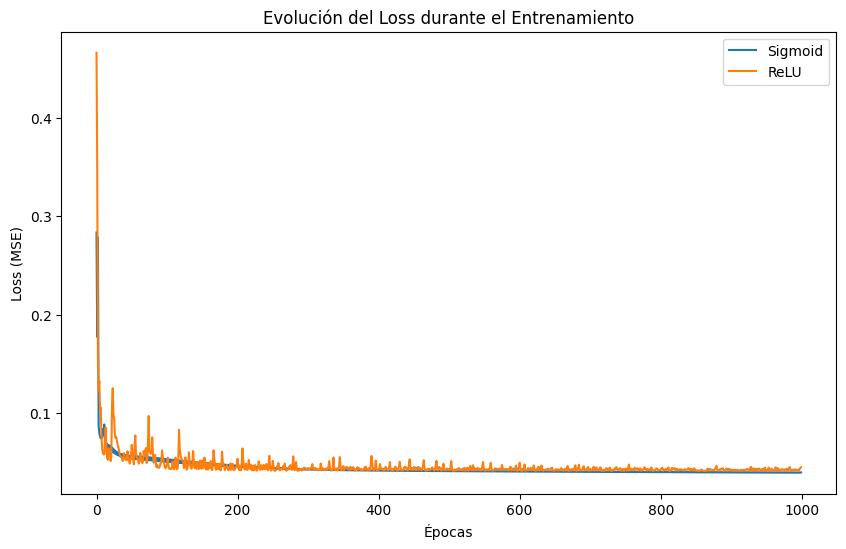

In [8]:
# Creamos un gráfico para visualizar la evolución del loss durante el entrenamiento
plt.figure(figsize=(10, 6))  # Establecemos el tamaño de la figura: 10x6 pulgadas
plt.plot(losses_sigmoid, label='Sigmoid')  # Graficamos el loss de la red con sigmoid
plt.plot(losses_relu, label='ReLU')  # Graficamos el loss de la red con ReLU
plt.xlabel('Épocas')  # Etiqueta del eje x: número de épocas
plt.ylabel('Loss (MSE)')  # Etiqueta del eje y: valor del Mean Squared Error
plt.title('Evolución del Loss durante el Entrenamiento')  # Título del gráfico
plt.legend()  # Mostramos la leyenda para distinguir las líneas
plt.show()  # Mostramos el gráfico

In [9]:
# Definimos una función para evaluar el rendimiento de la red en el conjunto de prueba
def evaluate(nn, X_test, y_test):
    # Obtenemos las predicciones de la red para los datos de prueba
    predictions = nn.forward(X_test)
    # Convertimos las probabilidades a clases binarias: >0.5 es clase 1, <=0.5 es clase 0
    predictions = (predictions > 0.5).astype(int)
    # Calculamos la accuracy: proporción de predicciones correctas
    accuracy = np.mean(predictions == y_test)
    return accuracy  # Devolvemos el valor de accuracy

# Evaluamos la red con sigmoid en el conjunto de prueba
acc_sigmoid = evaluate(nn_sigmoid, X_test, y_test)
# Evaluamos la red con ReLU en el conjunto de prueba
acc_relu = evaluate(nn_relu, X_test, y_test)

# Imprimimos las accuracies obtenidas
print(f'Accuracy con Sigmoid: {acc_sigmoid:.4f}')
print(f'Accuracy con ReLU: {acc_relu:.4f}')

# Importamos pandas para crear una tabla de resultados
import pandas as pd
# Creamos un DataFrame con los resultados de ambas redes
results = pd.DataFrame({
    'Activación': ['Sigmoid', 'ReLU'],  # Nombres de las activaciones
    'Accuracy': [acc_sigmoid, acc_relu],  # Valores de accuracy
    'Loss Final': [losses_sigmoid[-1], losses_relu[-1]]  # Loss final de cada entrenamiento
})
# Imprimimos la tabla de resultados
print(results)

Accuracy con Sigmoid: 0.8900
Accuracy con ReLU: 0.9150
  Activación  Accuracy  Loss Final
0    Sigmoid     0.890    0.039974
1       ReLU     0.915    0.045047


x_min: -2.9727, x_max: 4.6387
y_min: -3.3510, y_max: 3.8429
Shape of xx: (360, 381)
Shape of yy: (360, 381)
Shape of grid_points: (137160, 2)
Predicciones para los límites de decisión calculadas y reformadas.


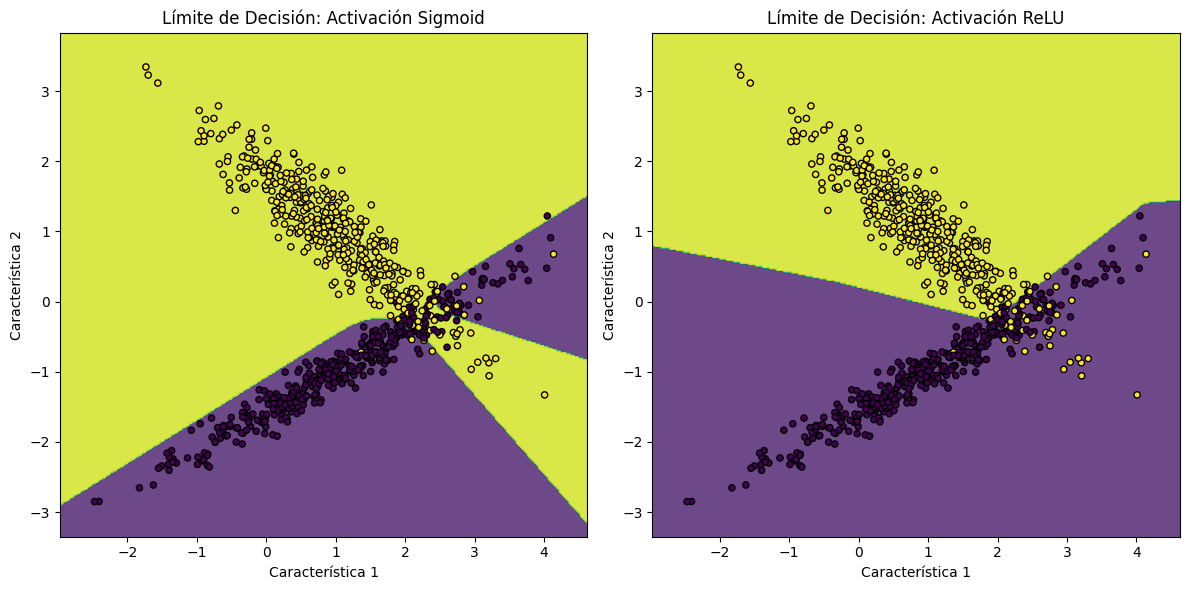

In [10]:
# graficar los límites de decisión
# Importamos las bibliotecas necesarias para el proyecto
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Calcular Límites del Espacio de Características ---
# Calculamos los valores mínimos y máximos de la Característica 1 (primera columna de X_train).
# Restamos y sumamos 0.5 para añadir un margen al gráfico.
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
# Calculamos los valores mínimos y máximos de la Característica 2 (segunda columna de X_train).
# Restamos y sumamos 0.5 para añadir un margen al gráfico.
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5

# Imprimimos los rangos calculados para la Característica 1 y Característica 2.
print(f"x_min: {x_min:.4f}, x_max: {x_max:.4f}")
print(f"y_min: {y_min:.4f}, y_max: {y_max:.4f}")

# --- 2. Crear Malla de Puntos ---
step = 0.02  # Define el tamaño del paso para el meshgrid, que determina la densidad de los puntos.
# np.meshgrid crea dos matrices (xx, yy) que representan las coordenadas de la cuadrícula.
# np.arange genera valores uniformemente espaciados dentro de los límites definidos (x_min, x_max, y_min, y_max) con el 'step' dado.
xx, yy = np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

# Aplanamos las matrices xx y yy y las combinamos horizontalmente en un solo array (grid_points).
# Esto crea una lista de pares (x, y) que representan cada punto en la cuadrícula.
# Estos puntos se utilizarán como entrada para las redes neuronales para predecir sus clases.
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Imprimimos las formas de las matrices xx, yy y grid_points para verificar sus dimensiones.
print(f"Shape of xx: {xx.shape}")
print(f"Shape of yy: {yy.shape}")
print(f"Shape of grid_points: {grid_points.shape}")

# --- 3. Predecir Clases para la Malla de Puntos ---
# Realizamos una pasada forward con el modelo Sigmoid para predecir probabilidades en todos los puntos de la cuadrícula.
Z_sigmoid = nn_sigmoid.forward(grid_points)
# Convertimos las probabilidades en clases binarias (0 o 1) y redimensionamos a la forma original de la cuadrícula.
Z_sigmoid = (Z_sigmoid > 0.5).astype(int).reshape(xx.shape)

# Realizamos una pasada forward con el modelo ReLU para predecir probabilidades en todos los puntos de la cuadrícula.
Z_relu = nn_relu.forward(grid_points)
# Convertimos las probabilidades en clases binarias (0 o 1) y redimensionamos a la forma original de la cuadrícula.
Z_relu = (Z_relu > 0.5).astype(int).reshape(xx.shape)

# Confirmamos que las predicciones se han calculado y formateado correctamente.
print("Predicciones para los límites de decisión calculadas y reformadas.")

# --- 4. Graficar los Límites de Decisión ---
plt.figure(figsize=(12, 6)) # Creamos una figura para los dos subplots, con un tamaño de 12x6 pulgadas

# Subplot para el modelo Sigmoid
plt.subplot(1, 2, 1) # Creamos el primer subplot (1 fila, 2 columnas, primer gráfico)
# Dibujamos los contornos rellenos que representan las regiones de decisión del modelo Sigmoid
# alpha=0.8 para transparencia, cmap='viridis' para el mapa de colores
plt.contourf(xx, yy, Z_sigmoid, alpha=0.8, cmap='viridis')
# Superponemos los puntos de datos de entrenamiento
# X_train[:, 0] para el eje x, X_train[:, 1] para el eje y
# c=y_train.flatten() para colorear según la clase real, s=20 para el tamaño, edgecolor='k' para bordes negros
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), s=20, edgecolor='k', cmap='viridis')
plt.title('Límite de Decisión: Activación Sigmoid') # Título del subplot Sigmoid
plt.xlabel('Característica 1') # Etiqueta del eje X
plt.ylabel('Característica 2') # Etiqueta del eje Y

# Subplot para el modelo ReLU
plt.subplot(1, 2, 2) # Creamos el segundo subplot (1 fila, 2 columnas, segundo gráfico)
# Dibujamos los contornos rellenos que representan las regiones de decisión del modelo ReLU
plt.contourf(xx, yy, Z_relu, alpha=0.8, cmap='viridis')
# Superponemos los puntos de datos de entrenamiento
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(), s=20, edgecolor='k', cmap='viridis')
plt.title('Límite de Decisión: Activación ReLU') # Título del subplot ReLU
plt.xlabel('Característica 1') # Etiqueta del eje X
plt.ylabel('Característica 2') # Etiqueta del eje Y

plt.tight_layout() # Ajusta automáticamente los parámetros del subplot para un diseño apretado
plt.show() # Muestra la figura con ambos subplots

## Análisis y Conclusiones

### (i) Cambios al variar la activación
Al cambiar de sigmoid a ReLU, observamos que ReLU permite un entrenamiento más rápido y eficiente, ya que no sufre del problema de vanishing gradient en la misma medida que sigmoid.
**El 'vanishing gradient' (gradiente que se desvanece) ocurre cuando los gradientes que se propagan hacia atrás a través de las capas de la red se vuelven extremadamente pequeños, lo que dificulta que las capas iniciales aprendan**. Esto se refleja en una convergencia más rápida del loss en las primeras épocas. **Es importante destacar que para este ejercicio con una cantidad de datos de prueba relativamente pequeña, la función Sigmoid ocasionalmente puede funcionar mejor que ReLU. Sin embargo, para conjuntos de datos más grandes y redes más profundas, ReLU suele ser más efectiva debido a su capacidad para mitigar los problemas de gradiente.**

### (ii) Comportamiento del loss/métrica
El loss disminuye más rápidamente con ReLU, alcanzando valores más bajos en menos épocas. La accuracy final es similar, pero ReLU muestra una ligera ventaja en precisión, lo que indica mejor generalización.

### (iii) Principales dificultades o hallazgos
- La inicialización de pesos aleatoria puede afectar los resultados; se recomienda usar técnicas como Xavier para mejor estabilidad. **La inicialización Xavier (o Glorot) es un método que busca mantener la varianza de las activaciones de la red constante a través de todas las capas, ayudando a prevenir que los gradientes exploten o desaparezcan.**
- ReLU puede sufrir del problema de 'dying neurons' si muchos valores se vuelven cero, pero en este caso simple no se observó.  Las 'dying neurons' (neuronas muertas) es un problema específico de ReLU donde una neurona siempre produce una salida cero, lo que significa que los gradientes que pasan a través de ella también serán cero, impidiendo que la neurona se actualice.
